In [2]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [3]:

df = pd.read_excel(
    "part_3_customer_churn_prediction.csv.xlsx"
)

print(df.head())

print(df.shape)

print(df.columns)

print(df.info())

print(df.isnull().sum())

  CustomerID  Gender  SeniorCitizen Partner Dependents  Tenure PhoneService  \
0   TEL00001    Male              0     Yes         No      42          Yes   
1   TEL00002  Female              0      No        Yes      55          Yes   
2   TEL00003  Female              0     Yes        Yes       0          Yes   
3   TEL00004  Female              0      No        Yes      16          Yes   
4   TEL00005    Male              0     Yes         No       6          Yes   

  MultipleLines InternetService       OnlineSecurity  ...  \
0           Yes     Fiber optic                  Yes  ...   
1           Yes     Fiber optic                  Yes  ...   
2            No             DSL                   No  ...   
3           Yes             DSL                   No  ...   
4            No              No  No internet service  ...   

      DeviceProtection          TechSupport          StreamingTV  \
0                   No                   No                   No   
1                   No

# Business Problem Understanding

Customer churn occurs when customers stop using a company’s service.

Churn is a major business problem because acquiring new customers is significantly more expensive than retaining existing customers.

Predicting churn helps businesses:
- identify high-risk customers
- take preventive action
- improve customer retention
- reduce revenue loss

Customer retention is important because loyal customers generate recurring revenue and improve long-term business stability.

In churn prediction, False Negatives are often more costly than False Positives.

- False Negative:
A customer is predicted to stay but actually leaves. This leads to lost revenue and missed retention opportunities.

- False Positive:
A customer is predicted to churn but actually stays. This may result in unnecessary retention offers, but the customer is not lost.

# Data Understanding

The dataset contains customer information for a telecom/subscription-based company.

Each row represents one customer.

## Important Columns

- CustomerID → unique customer identifier
- Gender → customer gender
- SeniorCitizen → senior citizen status
- Partner → whether customer has a partner
- Dependents → whether customer has dependents
- Tenure → number of months customer stayed
- Contract → contract type
- InternetService → internet service type
- PaymentMethod → payment method used
- MonthlyCharges → monthly payment amount
- TotalCharges → total amount paid
- Churn → whether customer left the service

## Numerical Columns
- Tenure
- MonthlyCharges
- TotalCharges

## Categorical Columns
- Gender
- Partner
- Dependents
- Contract
- InternetService
- PaymentMethod
- Churn

## Target Variable
- Churn

## Problem Type
This is a classification problem because the target variable contains categories (Yes/No).

## Why Supervised Learning?
The dataset already contains known churn labels, so the model learns from labeled examples.

In [4]:
df = df.drop_duplicates()

df = df.drop(columns=["CustomerID"])

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

print(df.isnull().sum())

print(df.head())

Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
   Gender  SeniorCitizen Partner Dependents  Tenure PhoneService  \
0    Male              0     Yes         No      42          Yes   
1  Female              0      No        Yes      55          Yes   
2  Female              0     Yes        Yes       0          Yes   
3  Female              0      No        Yes      16          Yes   
4    Male              0     Yes         No       6          Yes   

  MultipleLines InternetService       OnlineSecurity         OnlineBackup  \
0           Yes     Fiber optic                  Yes         

In [5]:
le = LabelEncoder()

categorical_cols = df.select_dtypes(
    include=["object"]
).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print(df.head())

   Gender  SeniorCitizen  Partner  Dependents  Tenure  PhoneService  \
0       1              0        1           0      42             1   
1       0              0        0           1      55             1   
2       0              0        1           1       0             1   
3       0              0        0           1      16             1   
4       1              0        1           0       6             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              2                1               2             0   
1              2                1               2             0   
2              0                0               0             0   
3              2                0               0             2   
4              0                2               1             1   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                2         1   
1                 

In [7]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

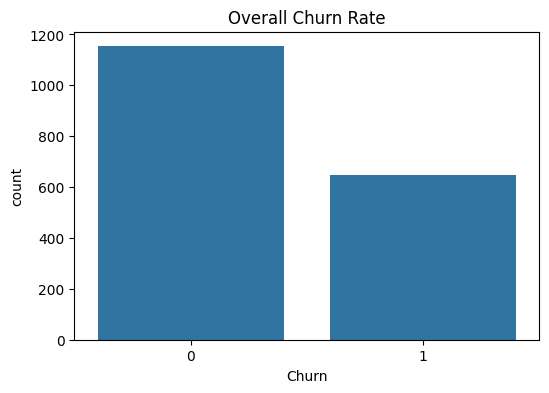

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(x=df["Churn"])

plt.title("Overall Churn Rate")

plt.show()

The chart shows the distribution of churned and non-churned customers.

A significant churn rate indicates customer retention challenges for the company.

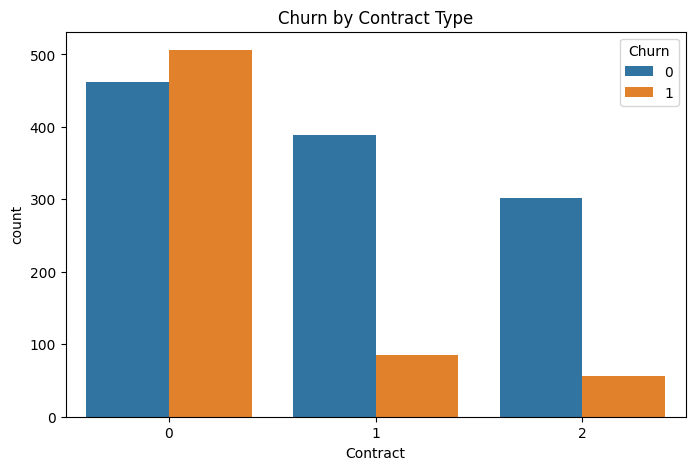

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Churn by Contract Type")

plt.show()

Customers with month-to-month contracts are more likely to churn compared to customers with long-term contracts.

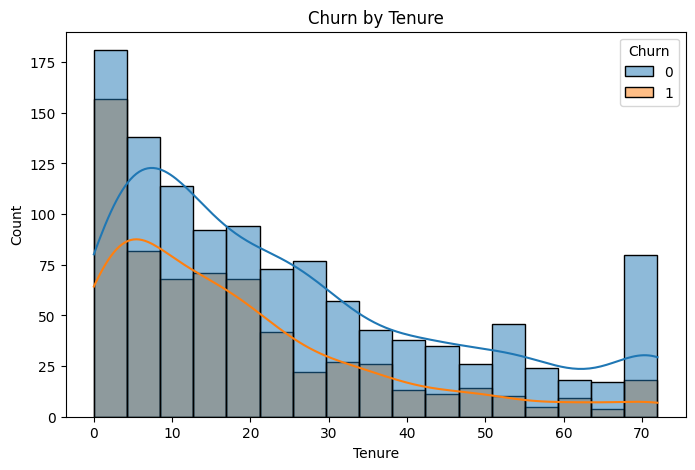

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Tenure",
    hue="Churn",
    kde=True
)

plt.title("Churn by Tenure")

plt.show()

Customers with shorter tenure show a higher probability of churn.

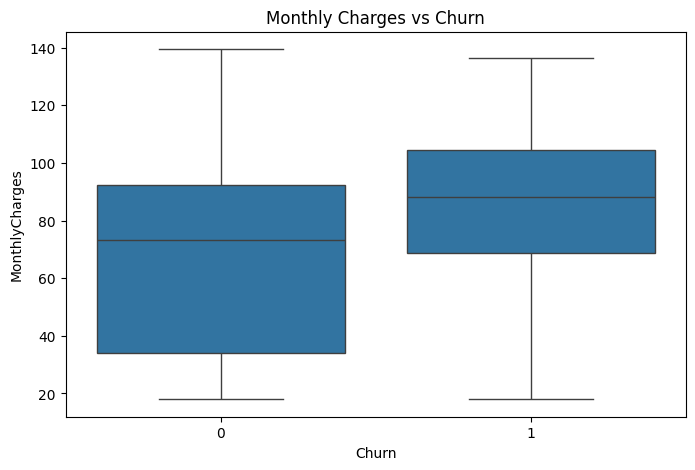

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.show()

Customers with higher monthly charges appear more likely to churn.

In [14]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [15]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [16]:
print("LOGISTIC REGRESSION")

print(
    "Accuracy:",
    accuracy_score(y_test, lr_pred)
)

print(
    confusion_matrix(y_test, lr_pred)
)

print(
    classification_report(y_test, lr_pred)
)

LOGISTIC REGRESSION
Accuracy: 0.6694444444444444
[[171  59]
 [ 60  70]]
              precision    recall  f1-score   support

           0       0.74      0.74      0.74       230
           1       0.54      0.54      0.54       130

    accuracy                           0.67       360
   macro avg       0.64      0.64      0.64       360
weighted avg       0.67      0.67      0.67       360



In [17]:
print("DECISION TREE")

print(
    "Accuracy:",
    accuracy_score(y_test, dt_pred)
)

print(
    confusion_matrix(y_test, dt_pred)
)

print(
    classification_report(y_test, dt_pred)
)

DECISION TREE
Accuracy: 0.6027777777777777
[[151  79]
 [ 64  66]]
              precision    recall  f1-score   support

           0       0.70      0.66      0.68       230
           1       0.46      0.51      0.48       130

    accuracy                           0.60       360
   macro avg       0.58      0.58      0.58       360
weighted avg       0.61      0.60      0.61       360



# Model Evaluation

## True Positive
Customer correctly predicted as churned.

## True Negative
Customer correctly predicted as not churned.

## False Positive
Customer predicted as churned but actually stayed.

## False Negative
Customer predicted as not churned but actually churned.

False Negatives are more dangerous because the company loses customers without taking preventive action.

Recall is very important in churn prediction because the business wants to identify as many churn-risk customers as possible.

In [18]:
lr_accuracy = accuracy_score(y_test, lr_pred)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

print("Decision Tree Accuracy:", dt_accuracy)

Logistic Regression Accuracy: 0.6694444444444444
Decision Tree Accuracy: 0.6027777777777777


# Final Model Selection

The final model was selected based on accuracy, recall, and overall business suitability.

In churn prediction, recall is especially important because missing churn-risk customers can result in revenue loss.

The selected model provides a better balance between identifying churn-risk customers and maintaining prediction accuracy.

In [19]:
probabilities = lr_model.predict_proba(X_test)[:,1]

risk_df = pd.DataFrame({
    "ChurnProbability": probabilities
})

risk_df["RiskLevel"] = pd.cut(
    risk_df["ChurnProbability"],
    bins=[0, 0.3, 0.7, 1],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

print(risk_df.head())

   ChurnProbability    RiskLevel
0          0.473269  Medium Risk
1          0.152845     Low Risk
2          0.052088     Low Risk
3          0.177562     Low Risk
4          0.275354     Low Risk


# Retention Recommendations

## High-Risk Customers
- provide retention discounts
- offer contract upgrades
- provide personalized customer support
- create loyalty programs

## Medium-Risk Customers
- offer targeted promotional campaigns
- recommend additional services
- improve customer engagement

## Low-Risk Customers
- maintain customer satisfaction
- reward loyalty
- provide long-term benefits

## Additional Recommendations
- encourage long-term contracts
- reduce churn among high monthly charge customers
- provide early engagement for new customers
- improve payment support and customer service

In [20]:
import os

os.makedirs("outputs", exist_ok=True)
os.makedirs("dataset", exist_ok=True)

In [21]:
df.to_csv(
    "dataset/cleaned_churn_data.csv",
    index=False
)

In [22]:
risk_df.to_csv(
    "outputs/churn_risk_levels.csv",
    index=False
)

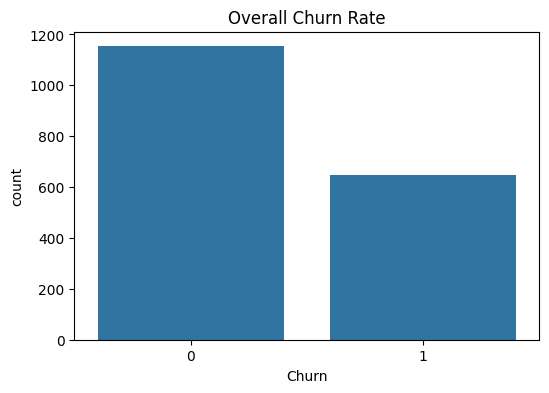

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(x=df["Churn"])

plt.title("Overall Churn Rate")

plt.savefig(
    "outputs/churn_rate.png",
    bbox_inches="tight"
)

plt.show()

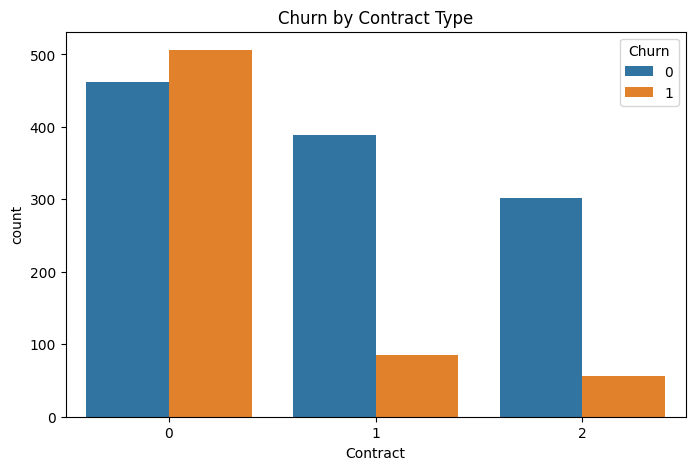

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Churn by Contract Type")

plt.savefig(
    "outputs/churn_by_contract.png",
    bbox_inches="tight"
)

plt.show()

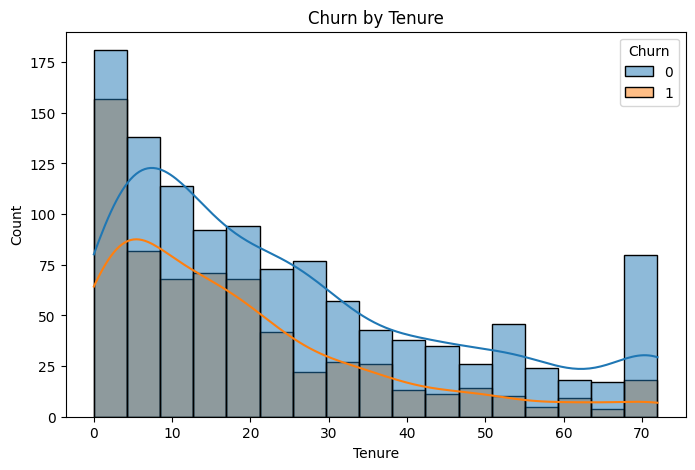

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Tenure",
    hue="Churn",
    kde=True
)

plt.title("Churn by Tenure")

plt.savefig(
    "outputs/churn_by_tenure.png",
    bbox_inches="tight"
)

plt.show()

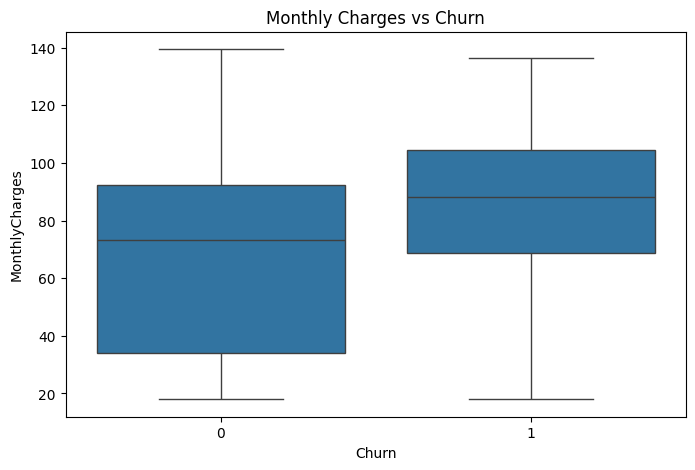

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.savefig(
    "outputs/monthly_charges_vs_churn.png",
    bbox_inches="tight"
)

plt.show()

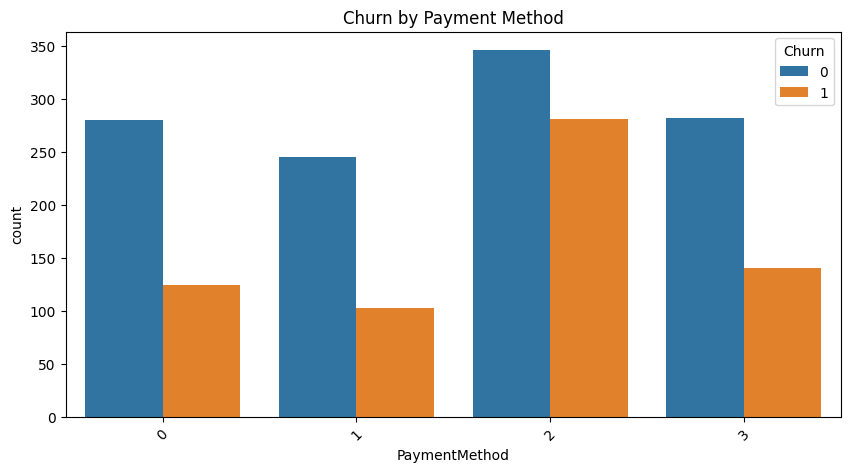

In [27]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

plt.xticks(rotation=45)

plt.title("Churn by Payment Method")

plt.savefig(
    "outputs/churn_by_payment.png",
    bbox_inches="tight"
)

plt.show()

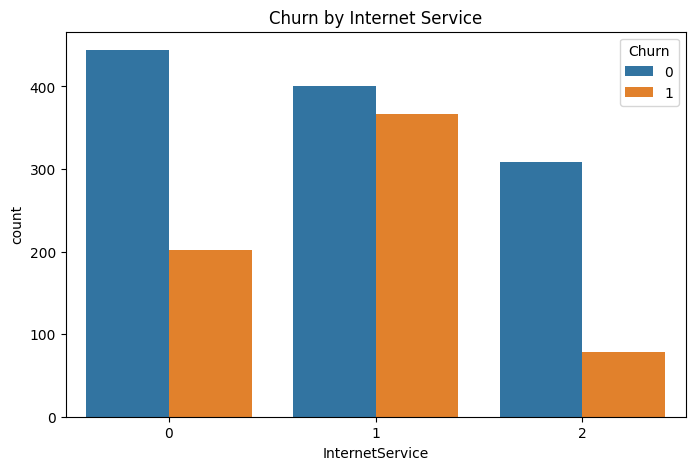

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.title("Churn by Internet Service")

plt.savefig(
    "outputs/churn_by_internet.png",
    bbox_inches="tight"
)

plt.show()

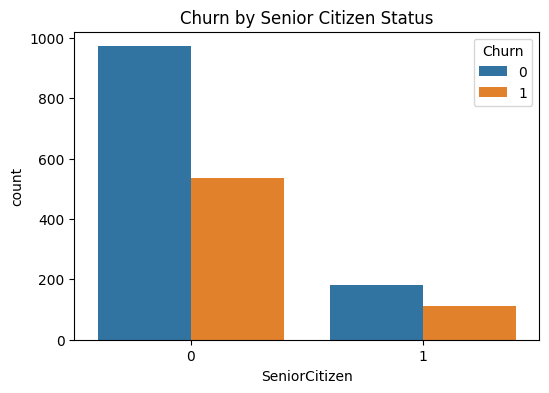

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="SeniorCitizen",
    hue="Churn",
    data=df
)

plt.title("Churn by Senior Citizen Status")

plt.savefig(
    "outputs/churn_by_seniorcitizen.png",
    bbox_inches="tight"
)

plt.show()

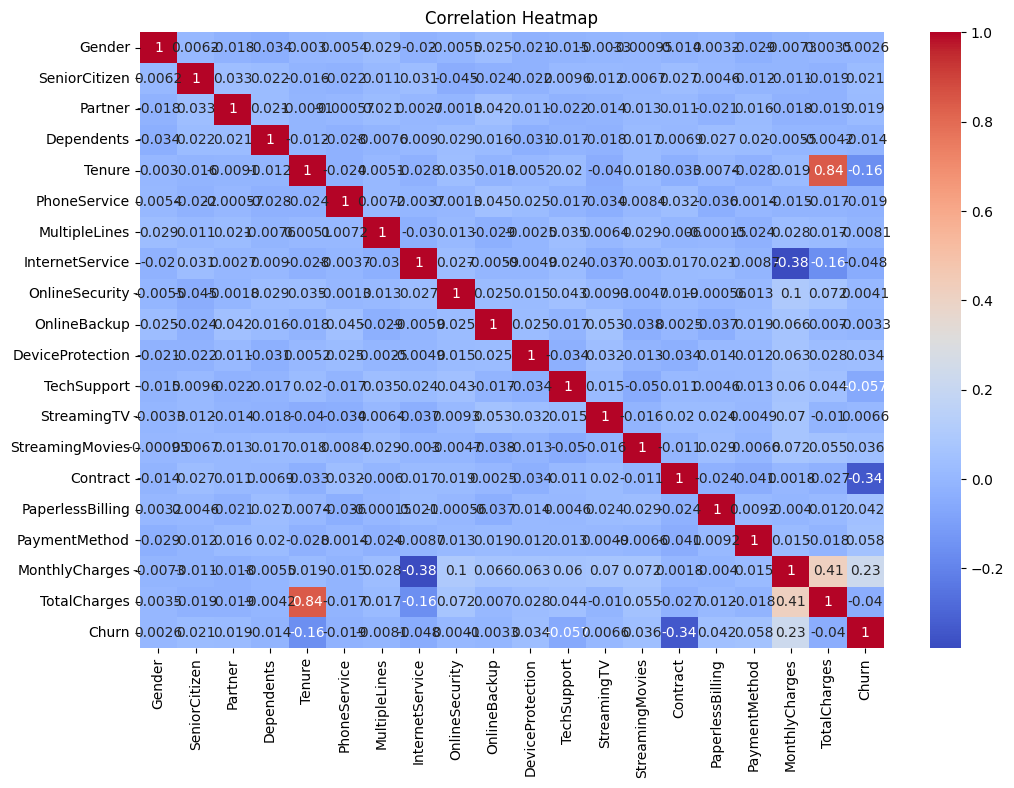

In [30]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "outputs/correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

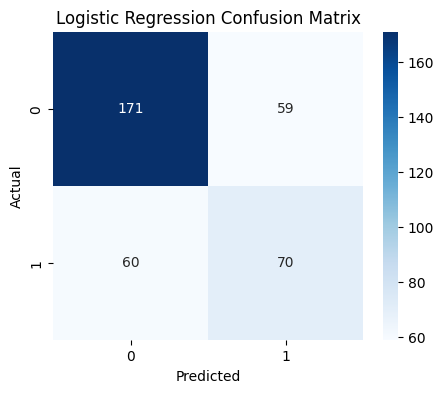

In [31]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "outputs/lr_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

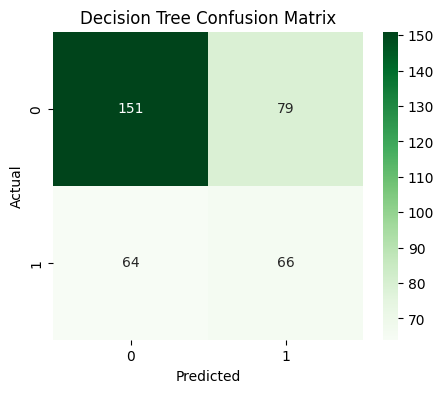

In [32]:
cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "outputs/dt_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

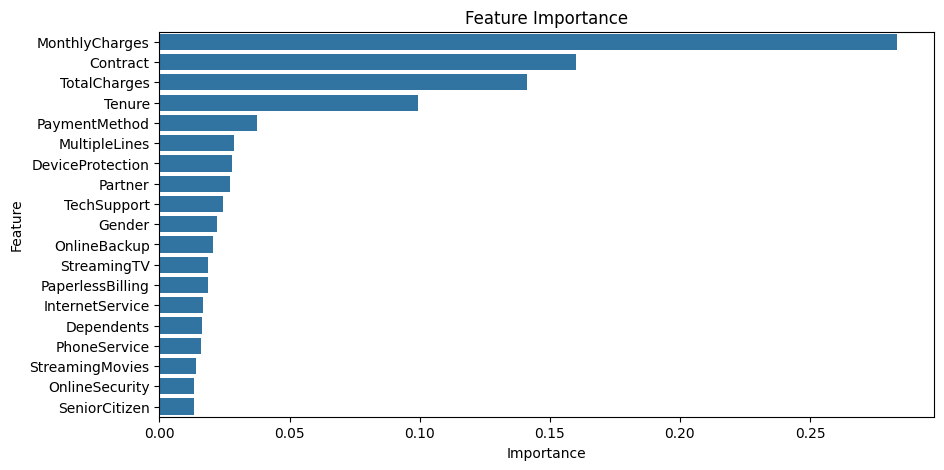

In [33]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(10,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.savefig(
    "outputs/feature_importance.png",
    bbox_inches="tight"
)

plt.show()